In [48]:
from astropy.table import Table
import fitsio
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

from pathlib import Path
plt.rcParams.update({'font.size': 13})

In [34]:
data_dir = Path("/global/cfs/cdirs/desi/public/dr1/spectro/redux/guadalupe/")
zcat = Table.read(data_dir / "zcatalog" / "v1" / "zall-pix-guadalupe.fits")


In [8]:
# Taken from visual inspection
# Nebula, weak CIII, CIV absorption, unusually high SNR
tids = [2324322353938434, 39627513722308253, 39627519661445969, 39627583226122331]

In [36]:
wmin, wmax, wdelta = 3600, 9824, 0.8
desi_wave = np.round(np.arange(wmin, wmax + wdelta, wdelta), 1)
cslice = {'B': slice(0, 2751), 'R': slice(2700, 5026), 'Z': slice(4900, 7781)}


In [87]:
def load_spec(row):
    # idx = np.where(truth["TARGETID"] == tid)[0][0]

    # row = tbl[idx]
    hpx = row["HEALPIX"]
    f_loc = data_dir / "healpix" / row["SURVEY"] / row["PROGRAM"] / str(int(hpx) // 100) / str(hpx)
    fname = f"coadd-main-dark-{hpx}.fits"
    
    with fitsio.FITS(f_loc / fname) as h:
        spec_tids = h["FIBERMAP"]["TARGETID"][:]
    
        idx = np.where(spec_tids == row["TARGETID"])[0][0]
    
        fl_out = np.zeros(len(desi_wave))
        iv_out = np.zeros_like(fl_out)
    
        # Quick and dirty camera coadds
        for c in ["B", "R", "Z"]:
            fl = h[f"{c}_FLUX"][idx:idx+1, :][0]
            iv = h[f"{c}_IVAR"][idx:idx+1, :][0]
    
            fl_out[cslice[c]] += fl * iv
            iv_out[cslice[c]] += iv   
            
            
    nz = iv_out != 0
    fl_out[nz] /= iv_out[nz]
    
    return fl_out, nz

In [88]:
colors = ["#5790fc", "#964a8b", "#e42536", "#f89c20"]


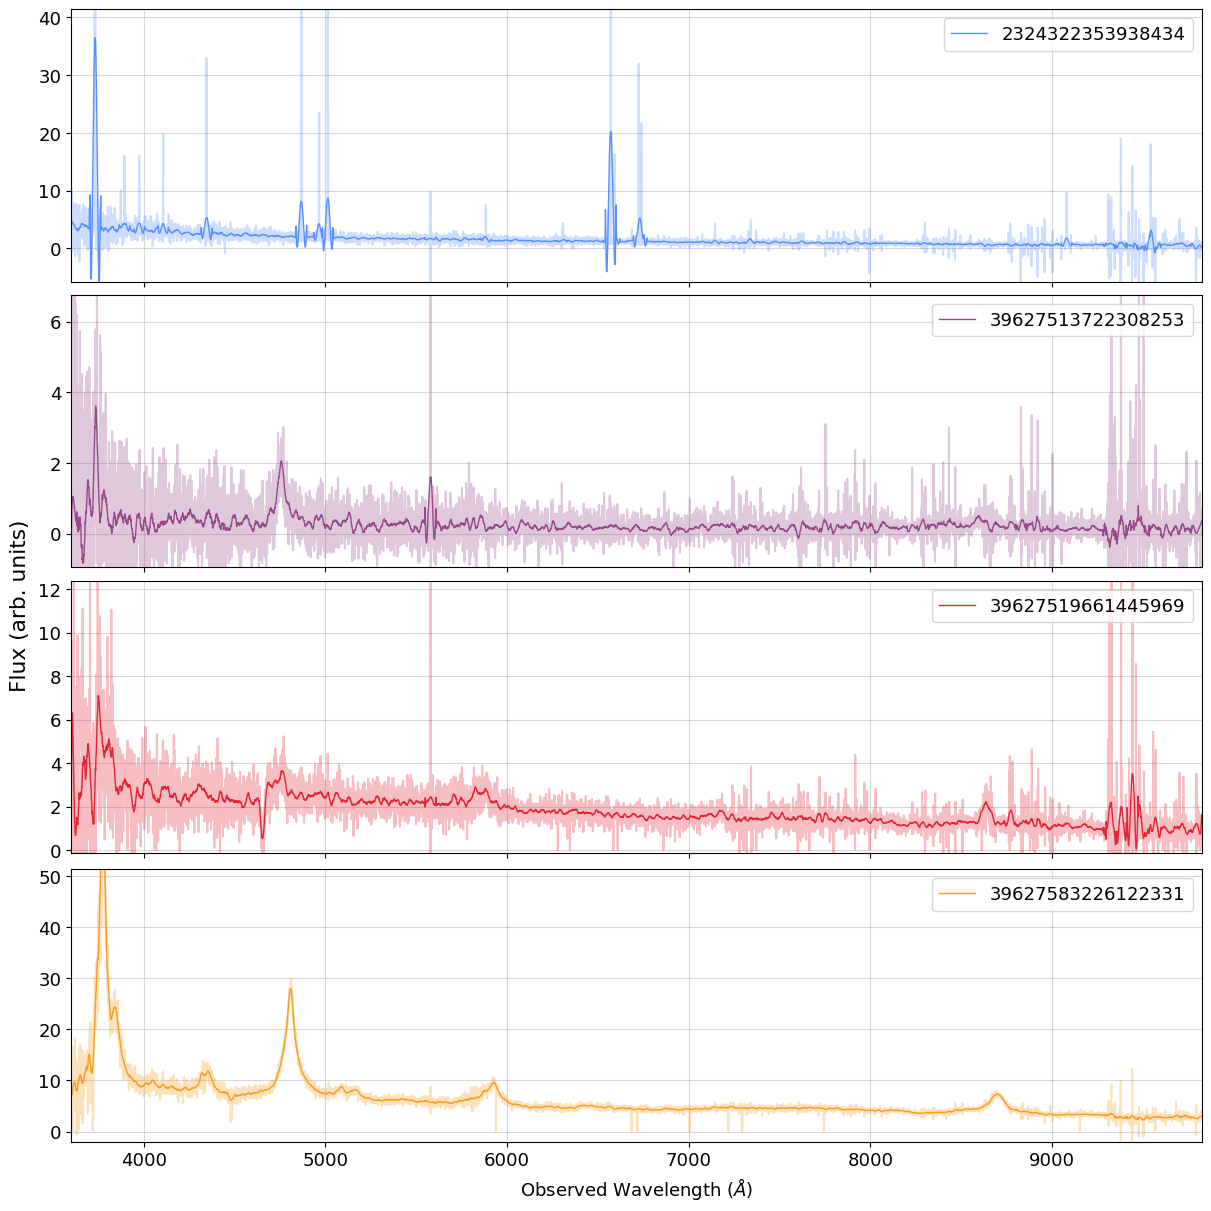

In [89]:
fig, ax = plt.subplots(len(tids), 1, figsize=(12, 12), layout="constrained")

for i, tid in enumerate(tids):
    idx = np.where(zcat["TARGETID"] == tid)[0][0]
    row = zcat[idx]
    fl, nz = load_spec(row)
    
    ax[i].plot(desi_wave, fl, c=colors[i], alpha=0.3)
    ax[i].plot(desi_wave[nz], savgol_filter(fl[nz], 75, 5), alpha=1, c=colors[i], lw=1, label=row["TARGETID"])

    mid = np.mean(fl)
    std = np.std(fl)

    ax[i].set(xlim=(desi_wave[0], desi_wave[-1]), ylim=(mid - 1.5*std, mid + 8*std))
    ax[i].grid(alpha=0.5)
    ax[i].legend(loc="upper right")
    if i < (len(tids) - 1):
        ax[i].set(xticklabels=[])
    else:
        ax[i].set(xlabel="Observed Wavelength ($\\AA$)")

fig.supylabel("Flux (arb. units)")
fig.savefig("plots/example_outliers.pdf", bbox_inches="tight")